### Importación de datos



In [21]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# 1. Análisis de facturación



In [22]:
nombres_tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
ingresos = [t['Precio'].sum() for t in tiendas]

print("INGRESO TOTAL POR TIENDA")
for nombre, valor in zip(nombres_tiendas, ingresos):
    print(f"{nombre:<10}: ${valor:,.2f}")

INGRESO TOTAL POR TIENDA
Tienda 1  : $1,150,880,400.00
Tienda 2  : $1,116,343,500.00
Tienda 3  : $1,098,019,600.00
Tienda 4  : $1,038,375,700.00


# 2. Ventas por categoría

In [29]:
# 2. Ventas por categoría
print("REPORTE DETALLADO DE VENTAS\n")

for i, t in enumerate(tiendas, 1):
    print(f"TIENDA {i}")
    
    conteo = t['Categoría del Producto'].value_counts().head(5)
    df_cat = conteo.reset_index()
    df_cat.columns = ['Categoría', 'Ventas'] 
    
    print(df_cat.to_string(index=False))
    print("-" * 40)

REPORTE DETALLADO DE VENTAS

TIENDA 1
           Categoría  Ventas
             Muebles     465
        Electrónicos     448
            Juguetes     324
   Electrodomésticos     312
Deportes y diversión     284
----------------------------------------
TIENDA 2
           Categoría  Ventas
             Muebles     442
        Electrónicos     422
            Juguetes     313
   Electrodomésticos     305
Deportes y diversión     275
----------------------------------------
TIENDA 3
           Categoría  Ventas
             Muebles     499
        Electrónicos     451
            Juguetes     315
   Electrodomésticos     278
Deportes y diversión     277
----------------------------------------
TIENDA 4
           Categoría  Ventas
             Muebles     480
        Electrónicos     451
            Juguetes     338
Deportes y diversión     277
   Electrodomésticos     254
----------------------------------------


# 3. Calificación promedio de la tienda


In [33]:
print("CALIFICACIÓN PROMEDIO DE CLIENTES\n")
for i, t in enumerate(tiendas, 1):
    calif = t['Calificación'].mean()
    print(f"Tienda {i}: {calif:.2f}")

CALIFICACIÓN PROMEDIO DE CLIENTES

Tienda 1: 3.98
Tienda 2: 4.04
Tienda 3: 4.05
Tienda 4: 4.00


# 4. Productos más y menos vendidos

In [37]:
print("TOPS Y BOTTOMS POR TIENDA\n")
for i, t in enumerate(tiendas, 1):
    conteo = t['Producto'].value_counts()
    print(f"TIENDA {i}:")
    print(f"Más vendido: {conteo.idxmax()} ({conteo.max()})")
    print(f"Menos vendido: {conteo.idxmin()} ({conteo.min()})")
    print("-" * 30)

TOPS Y BOTTOMS POR TIENDA

TIENDA 1:
Más vendido: Microondas (60)
Menos vendido: Auriculares con micrófono (33)
------------------------------
TIENDA 2:
Más vendido: Iniciando en programación (65)
Menos vendido: Juego de mesa (32)
------------------------------
TIENDA 3:
Más vendido: Kit de bancas (57)
Menos vendido: Bloques de construcción (35)
------------------------------
TIENDA 4:
Más vendido: Cama box (62)
Menos vendido: Guitarra eléctrica (33)
------------------------------


# 5. Envío promedio por tienda

In [39]:
print("COSTO DE ENVÍO PROMEDIO POR TIENDA\n")
for i, t in enumerate(tiendas, 1):
    envio = t['Costo de envío'].mean()
    print(f"Tienda {i}: ${envio:,.2f}")

COSTO DE ENVÍO PROMEDIO POR TIENDA

Tienda 1: $26,018.61
Tienda 2: $25,216.24
Tienda 3: $24,805.68
Tienda 4: $23,459.46


# 6. Generación de gráficos

In [45]:
import matplotlib.pyplot as plt

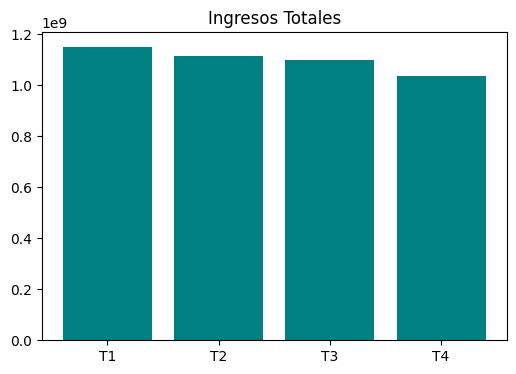

In [46]:
# Gráfico de Barras (Ingresos)
plt.figure(figsize=(6,4))
plt.bar(["T1", "T2", "T3", "T4"], [t['Precio'].sum() for t in tiendas], color='teal')
plt.title("Ingresos Totales")
plt.show()


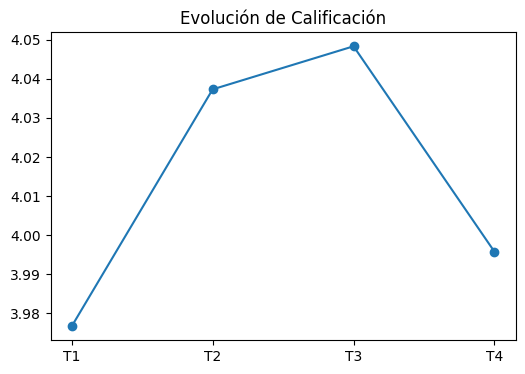

In [43]:
# Gráfico de Líneas (Calificaciones)
plt.figure(figsize=(6,4))
plt.plot(["T1", "T2", "T3", "T4"], [t['Calificación'].mean() for t in tiendas], marker='o')
plt.title("Evolución de Calificación")
plt.show()

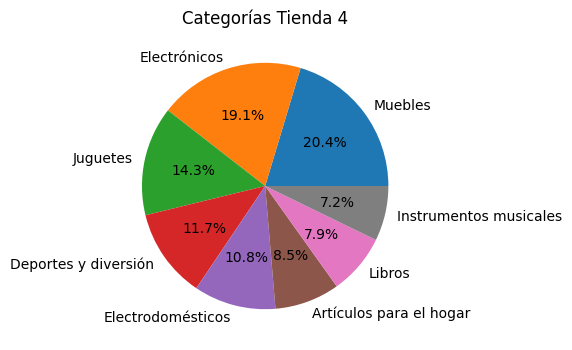

In [47]:
# Gráfico de Histograma (Distribución Tienda 4)
plt.figure(figsize=(6,4))
tiendas[3]['Categoría del Producto'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Categorías Tienda 4")
plt.show()